# 🧹 Data Cleaning Project

### Oasis Infobyte Internship — Data Analytics | Level 1, Task 3

**Name:** Param Parag Koli  
**Batch:** July 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📂 Step 1 — Load Dataset & Initial Inspection

In [2]:
df = pd.read_csv('/content/Titanic-Dataset.csv')

print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nNull Values:\n", df.isnull().sum())

df.head()

Shape: (891, 12)

Column Names:
 ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Null Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 🔍 Step 2 — Dataset Summary Statistics

In [3]:
numerical_cols = df.select_dtypes(include=np.number)

print("Mean")
print(numerical_cols.mean())

print("\nMedian")
print(numerical_cols.median())

print("\nMode")
print(numerical_cols.mode().iloc[0])

print("\nStandard Deviation")
print(numerical_cols.std())

Mean
PassengerId    446.000000
Survived         0.383838
Pclass           2.308642
Age             29.699118
SibSp            0.523008
Parch            0.381594
Fare            32.204208
dtype: float64

Median
PassengerId    446.0000
Survived         0.0000
Pclass           3.0000
Age             28.0000
SibSp            0.0000
Parch            0.0000
Fare            14.4542
dtype: float64

Mode
PassengerId     1.00
Survived        0.00
Pclass          3.00
Age            24.00
SibSp           0.00
Parch           0.00
Fare            8.05
Name: 0, dtype: float64

Standard Deviation
PassengerId    257.353842
Survived         0.486592
Pclass           0.836071
Age             14.526497
SibSp            1.102743
Parch            0.806057
Fare            49.693429
dtype: float64


### Observation

The dataset contains both numerical and categorical variables. Some columns have missing values and will require cleaning before analysis. The summary statistics provide an overview of passenger demographics and survival-related attributes.

## 🧹 Step 3 — Data Cleaning

In [4]:
before_summary = pd.DataFrame({
    "Rows": [df.shape[0]],
    "Duplicates": [df.duplicated().sum()],
    "Missing Values": [df.isnull().sum().sum()]
}, index=["Before Cleaning"])

df_clean = df.copy()

df_clean = df_clean.drop_duplicates()

df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

df_clean = df_clean.drop(columns=["Cabin"])

after_summary = pd.DataFrame({
    "Rows": [df_clean.shape[0]],
    "Duplicates": [df_clean.duplicated().sum()],
    "Missing Values": [df_clean.isnull().sum().sum()]
}, index=["After Cleaning"])

comparison = pd.concat([before_summary, after_summary])

comparison

,Rows,Duplicates,Missing Values
Before Cleaning,891,0,866
After Cleaning,891,0,0


### Observation

Missing values were handled using median and mode imputation where appropriate. Duplicate records were removed, and the Cabin column was dropped because it contained a large number of missing values. The cleaned dataset is now ready for further analysis.

## 📊 Step 4 — Missing Values Before vs After Cleaning

In [5]:
missing_before = df.isnull().sum()
missing_after = df_clean.isnull().sum()

comparison_missing = pd.DataFrame({
    "Before": missing_before,
    "After": missing_after
})

comparison_missing

,Before,After
Age,177,0.0
Cabin,687,NaN
Embarked,2,0.0
Fare,0,0.0
Name,0,0.0
Parch,0,0.0
PassengerId,0,0.0
Pclass,0,0.0
Sex,0,0.0
SibSp,0,0.0


### Observation

The number of missing values has been significantly reduced. Age and Embarked were successfully imputed, while Cabin was removed due to excessive missing data.

## 📈 Step 5 — Passenger Age Distribution

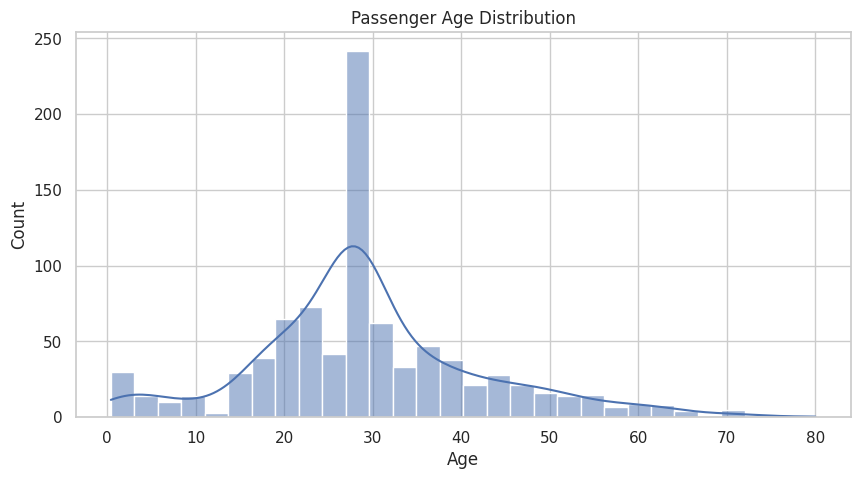

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(df_clean['Age'], bins=30, kde=True)
plt.title("Passenger Age Distribution")
plt.show()

### Observation

Most passengers were between 20 and 40 years old. The distribution is slightly right-skewed, indicating fewer older passengers compared to younger adults.

## 🚢 Step 6 — Survival Count Analysis

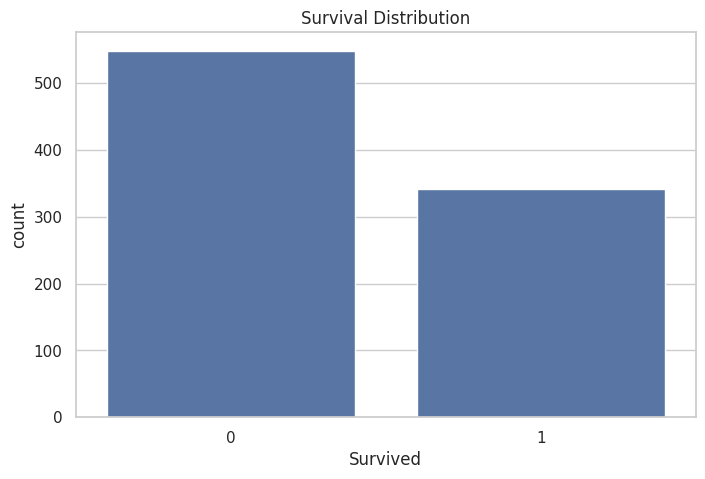

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(x='Survived', data=df_clean)
plt.title("Survival Distribution")
plt.show()

### Observation

The dataset shows that the number of passengers who did not survive was higher than those who survived. This indicates an imbalanced distribution between the two groups.

## 👨‍👩‍👧‍👦 Step 7 — Survival by Gender

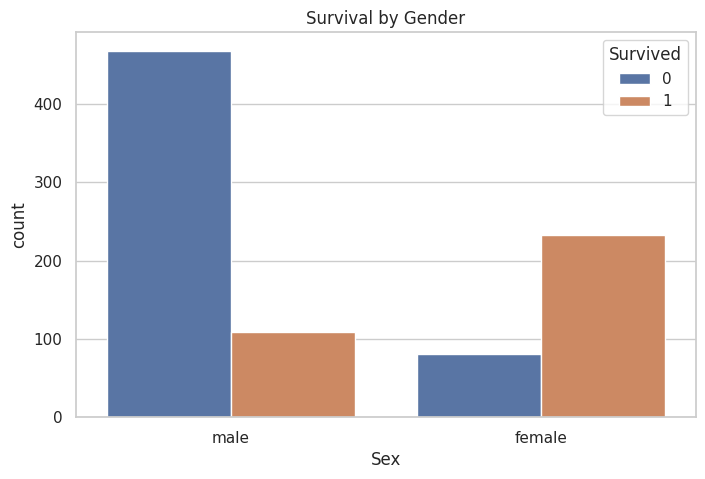

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(x='Sex', hue='Survived', data=df_clean)
plt.title("Survival by Gender")
plt.show()

### Observation

Female passengers had a significantly higher survival rate compared to male passengers. This suggests that gender played an important role in survival outcomes.

## 🔥 Step 8 — Correlation Heatmap

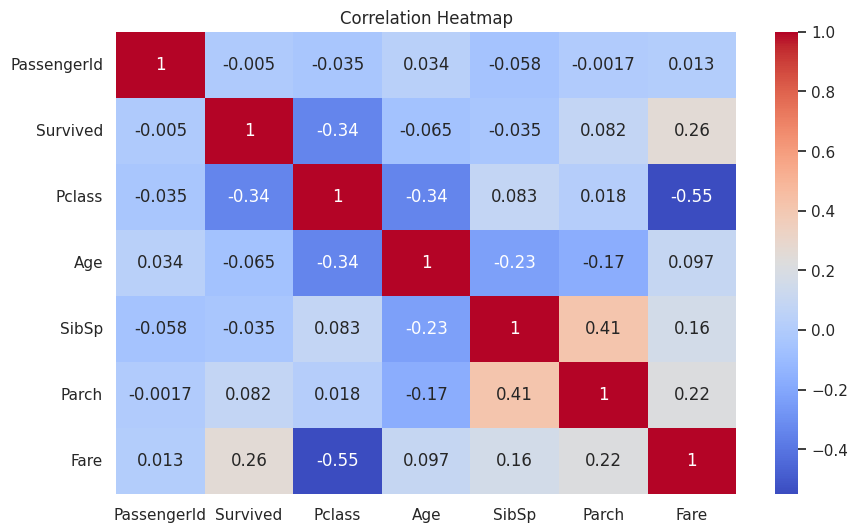

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(df_clean.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Observation

The heatmap reveals relationships between numerical variables. Survival shows a moderate negative correlation with Passenger Class, indicating passengers in higher classes generally had better survival chances.

## 📋 Step 9 — Data Type Validation

In [10]:
dtype_summary = pd.DataFrame({
    "Column": df_clean.columns,
    "Data Type": df_clean.dtypes.astype(str)
})

dtype_summary

,Column,Data Type
PassengerId,PassengerId,int64
Survived,Survived,int64
Pclass,Pclass,int64
Name,Name,object
Sex,Sex,object
Age,Age,float64
SibSp,SibSp,int64
Parch,Parch,int64
Ticket,Ticket,object
Fare,Fare,float64


### Observation

All columns now have appropriate data types for analysis. Numerical variables can be used for statistical analysis, while categorical variables are ready for grouping and visualization.

## 💾 Step 10 — Save Cleaned Dataset

In [11]:
df_clean.to_csv("Cleaned_Titanic_Dataset.csv", index=False)

print("✅ Cleaned dataset saved successfully!")

✅ Cleaned dataset saved successfully!


## 🎯 Conclusion

### Key Findings

1. Missing values in Age and Embarked were successfully handled, improving data quality.

2. The majority of passengers were between 20 and 40 years old, making this the dominant age group in the dataset.

3. Female passengers had a noticeably higher survival rate than male passengers.

4. Passenger class showed a relationship with survival outcomes, suggesting socioeconomic factors influenced survival chances.

### Data Cleaning Techniques Applied

- Missing value treatment
- Duplicate removal
- Column removal for excessive missing data
- Data type validation

### Outcome

The dataset is now clean, consistent, and ready for machine learning or advanced analytics tasks.